In [11]:

import pandas as pd
import requests
import io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
response = requests.get(url)
df = pd.read_excel(io.BytesIO(response.content))

print("Данные загружены")
print(f"Строк: {len(df)}")
df.head()

Данные загружены
Строк: 541909


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:

print("ПРОБЛЕМЫ В ДАННЫХ:")
print("-" * 40)
print(f"Всего строк: {len(df)}")
print(f"Пропуски CustomerID: {df['CustomerID'].isna().sum()} ({df['CustomerID'].isna().mean()*100:.1f}%)")
print(f"Quantity <= 0: {(df['Quantity'] <= 0).sum()} ({(df['Quantity'] <= 0).mean()*100:.1f}%)")
print(f"UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()} ({(df['UnitPrice'] <= 0).mean()*100:.1f}%)")
print(f"Пропуски Description: {df['Description'].isna().sum()} ({df['Description'].isna().mean()*100:.1f}%)")

ПРОБЛЕМЫ В ДАННЫХ:
----------------------------------------
Всего строк: 541909
Пропуски CustomerID: 135080 (24.9%)
Quantity <= 0: 10624 (2.0%)
UnitPrice <= 0: 2517 (0.5%)
Пропуски Description: 1454 (0.3%)


In [17]:
#  первый датасет
df1 = df.copy()

print(f"Было строк: {len(df1)}")


df1 = df1.dropna(subset=['CustomerID'])
print(f"После удаления строк без CustomerID: {len(df1)}")


df1 = df1[df1['Quantity'] > 0]
print(f"После удаления Quantity <= 0: {len(df1)}")


df1 = df1[df1['UnitPrice'] > 0]
print(f"После удаления UnitPrice <= 0: {len(df1)}")

print(f"\n ПЕРВЫЙ ДАТАСЕТ ГОТОВ. Строк: {len(df1)}")

# Сохраняем
df1.to_csv('dataset_1.csv', index=False)
print("Файл сохранён как dataset_1.csv")

Было строк: 541909
После удаления строк без CustomerID: 406829
После удаления Quantity <= 0: 397924
После удаления UnitPrice <= 0: 397884

 ПЕРВЫЙ ДАТАСЕТ ГОТОВ. Строк: 397884
Файл сохранён как dataset_1.csv


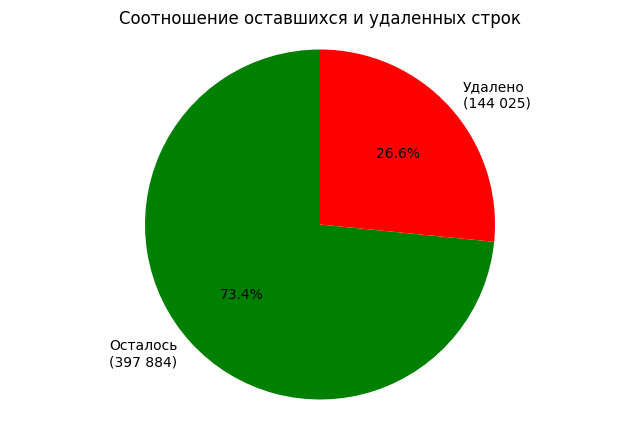

In [18]:

import matplotlib.pyplot as plt


categories = ['Осталось\n(397 884)', 'Удалено\n(144 025)']
values = [397884, 144025]
colors = ['green', 'red']

plt.figure(figsize=(8, 5))
plt.pie(values, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Соотношение оставшихся и удаленных строк')
plt.axis('equal')
plt.show()

In [13]:

from google.colab import files
files.download('dataset_1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:

# ВТОРОЙ ДАТАСЕТ
print("НАЧИНАЕМ СОЗДАВАТЬ ДАТАСЕТ ДЛЯ ПРОГНОЗА")

df2 = df.copy()
print(f"Исходных строк: {len(df2)}")

# Вместо удаления - создаём признак "анонимный клиент"
df2['IsAnonymous'] = df2['CustomerID'].isna().astype(int)
# Заполняем пустые ID временным значением -1
df2['CustomerID'] = df2['CustomerID'].fillna(-1)

print(f"Создан признак IsAnonymous. Анонимных клиентов: {df2['IsAnonymous'].sum()}")

df2['IsReturn'] = (df2['Quantity'] < 0).astype(int)

df2['AbsQuantity'] = df2['Quantity'].abs()

print(f"Создан признак IsReturn. Возвратов: {df2['IsReturn'].sum()}")


df2 = df2[df2['UnitPrice'] > 0]
print(f"После удаления некорректных цен: {len(df2)} строк")


df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'])
df2['Year'] = df2['InvoiceDate'].dt.year
df2['Month'] = df2['InvoiceDate'].dt.month
df2['Day'] = df2['InvoiceDate'].dt.day
df2['DayOfWeek'] = df2['InvoiceDate'].dt.dayofweek  # 0=пн, 6=вс
df2['Hour'] = df2['InvoiceDate'].dt.hour
df2['IsWeekend'] = (df2['DayOfWeek'] >= 5).astype(int)

print("Признаки из даты созданы")


df2['TotalSpent'] = df2['Quantity'] * df2['UnitPrice']


df2['Description'] = df2['Description'].fillna('Unknown')


print(f"\n ВТОРОЙ ДАТАСЕТ ГОТОВ")
print(f"Строк: {len(df2)}")
print(f"Колонок: {len(df2.columns)}")
print(f"\nКолонки: {list(df2.columns)}")

print("\nПервые 5 строк:")
df2.head()

НАЧИНАЕМ СОЗДАВАТЬ ДАТАСЕТ ДЛЯ ПРОГНОЗА
Исходных строк: 541909
Создан признак IsAnonymous. Анонимных клиентов: 135080
Создан признак IsReturn. Возвратов: 10624
После удаления некорректных цен: 539392 строк
Признаки из даты созданы

 ВТОРОЙ ДАТАСЕТ ГОТОВ
Строк: 539392
Колонок: 18

Колонки: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsAnonymous', 'IsReturn', 'AbsQuantity', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'IsWeekend', 'TotalSpent']

Первые 5 строк:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsAnonymous,IsReturn,AbsQuantity,Year,Month,Day,DayOfWeek,Hour,IsWeekend,TotalSpent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,0,6,2010,12,1,2,8,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,6,2010,12,1,2,8,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,0,8,2010,12,1,2,8,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,6,2010,12,1,2,8,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,6,2010,12,1,2,8,0,20.34


In [15]:

df2.to_csv('dataset_2_for_prediction.csv', index=False)
print("Файл сохранён как dataset_2_for_prediction.csv")

from google.colab import files
files.download('dataset_2_for_prediction.csv')
print("Скачивание началось")

Файл сохранён как dataset_2_for_prediction.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачивание началось


In [19]:
# Сравнение датасетов
print("СРАВНЕНИЕ ДАТАСЕТОВ:")
print("-" * 40)
print(f"Первый датасет: {df1.shape[0]} строк, {df1.shape[1]} колонок")
print(f"Второй датасет: {df2.shape[0]} строк, {df2.shape[1]} колонок")
print(f"\nКолонки первого: {list(df1.columns)}")
print(f"\nКолонки второго: {list(df2.columns)}")

СРАВНЕНИЕ ДАТАСЕТОВ:
----------------------------------------
Первый датасет: 397884 строк, 8 колонок
Второй датасет: 539392 строк, 18 колонок

Колонки первого: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Колонки второго: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsAnonymous', 'IsReturn', 'AbsQuantity', 'Year', 'Month', 'Day', 'DayOfWeek', 'Hour', 'IsWeekend', 'TotalSpent']
